#**Detección y Diagnóstico de Fallos en Centros de Mecanizado**

---
## **Opción de regresar a la Fase de Análisis**

**Paso anterior:** [🚀 Volver al Cuaderno 01: Análisis EDA](https://colab.research.google.com/drive/1nghG4Wt2FCo8IpQp6EpRmpq7lO_TFROl?authuser=1#scrollTo=wYbAwxyU_R3Q)


---

##**Comenzamos con la importación de las librerías y el dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

ruta = "/content/ai4i2020.csv"

df = pd.read_csv(ruta)

###Renombramos columnas, quitamos unidades

In [ ]:
df.columns = ['UDI', 'Product_ID', 'Type', 'Air_temperature',
       'Process_temperature', 'Rotational_speed', 'Torque',
       'Tool_wear', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF']

###Eliminamos variables que no necesitamos

In [ ]:
df.drop(columns=['UDI', 'Product_ID'], inplace=True)

###**Crear la variable del esfuerzo mecánico y la de diferencia de temperatura**

In [ ]:
df['Mechanical_Effort'] = df['Torque'] * df['Tool_wear']
df['Temp_Diff'] = df['Process_temperature'] - df['Air_temperature']

Aunque el `Torque` por sí solo es un buen indicador, la combinación multiplicativa con el desgaste `Mechanical Effort` actúa como un proxy del estrés acumulado en la estructura de la herramienta, permitiendo una separación de clases mucho más limpia para los fallos de tipo OSF.

##**2. Model Training and Optimization**

##**🏗️ Paso 1: Limpieza y Definición del Target**

Vamos a crear un target binario real basado en fallos físicos y eliminaremos las instancias que solo contienen ruido aleatorio.

###1. Eliminar filas donde SOLO hay RNF (porque no son fallos físicos)

In [ ]:
# Si RNF es 1 pero los demás son 0, es puro ruido.
df_clean = df.drop(df[(df['RNF'] == 1) & (df['Machine_failure'] == 1)].index)

###2. Definir nuestro Target Binario "Real" (Fisico)

In [ ]:
# Un fallo es real si ocurre cualquiera de los 4 tipos físicos
physical_failures = ['TWF', 'HDF', 'PWF', 'OSF']
df_clean['Target'] = df_clean[physical_failures].any(axis=1).astype(int)

In [ ]:
df_clean['Target'].value_counts()

,count
Target,
0,9670
1,329


###3. Seleccionar Features. Incluimos las que creamos en el EDA.

In [ ]:
# Quitamos los indicadores de fallo individuales para no hacer "data leakage"
features = ['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Temp_Diff', 'Mechanical_Effort']
X = df_clean[features]
y = df_clean['Target']

##**⚙️ Paso 2: Preprocesamiento Industrial**

En este siguiente paso es donde aplicaremos los criterios de ingeniería:

* **Ordinal Encoding para Type:** La columna Type (L, M, H) representa la calidad del producto (Low, Medium, High). No es una categoría cualquiera; tiene un orden. Los productos "Low" suelen tener tolerancias más ajustadas y fallar más.

* **Escalado (StandardScaler):** La velocidad (1500 RPM) y el Torque (40 Nm) tienen magnitudes muy distintas. Para que el modelo no se "maree" con los números grandes, normalizamos.

####1. Encoding de la columna 'Type' (L=0, M=1, H=2)

In [ ]:
encoder = OrdinalEncoder(categories=[['L', 'M', 'H']])
X.loc[:, 'Type'] = encoder.fit_transform(X[['Type']])

####2. Split Estratificado (Vital por el desbalanceo)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

####3. Escalado de variables numéricas

In [ ]:
scaler = StandardScaler()
# Escalamos todo excepto 'Type' (que ya es 0, 1, 2)
cols_to_scale = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Temp_Diff', 'Mechanical_Effort']

X_train.loc[:, cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test.loc[:, cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"Dataset listo. Proporción de fallos en Train: {y_train.mean():.2%}")

Dataset listo. Proporción de fallos en Train: 3.29%


/tmp/ipykernel_4499/203482252.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.36593848  0.02756556 -0.167525   ... -0.2678573   0.69087349
  0.04986163]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
/tmp/ipykernel_4499/203482252.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.08812122  0.60463713 -1.30044832 ...  0.06932386  1.43909604
 -0.22982179]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
/tmp/ipykernel_4499/203482252.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.41217268  1.10335068 -0.68033449 ...  2.04

##**El Primer Modelo**

Ahora que los datos están "limpios y brillantes", es hora de lanzar el primer clasificador. Dado que buscamos explicabilidad, empezaremos por utilizar un Random Forest (RF); y de cara a mejorar las métricas del modelo, utilizaremos el famoso XGBoost (XGB):

* **Random Forest:** El estándar de oro. Es robusto, maneja bien el desbalanceo y nos da el "Feature Importance" de forma nativa.

* **XGBoost:** Más potente, pero requiere un poco más de ajuste.

###**Random Forest**

**Como tenemos un desbalanceo de clases importante (en este caso, pocos fallos de la máquina)**, vamos a usar el parámetro class_weight='balanced'.
No solo miramos el **Accuracy**, sino que nos centramos en la **Matriz de Confusión**.

####**Entrenamiento del Baseline (Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Instanciar el modelo con pesos balanceados
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# 2. Entrenamiento
rf_model.fit(X_train, y_train)

# 3. Predicción
y_pred = rf_model.predict(X_test)

# 4. Evaluación técnica
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.82      0.77      0.80        66

    accuracy                           0.99      2000
   macro avg       0.91      0.88      0.90      2000
weighted avg       0.99      0.99      0.99      2000



###**La Evaluación "Industrial" (Matriz de Confusión)**

<Figure size 800x600 with 0 Axes>

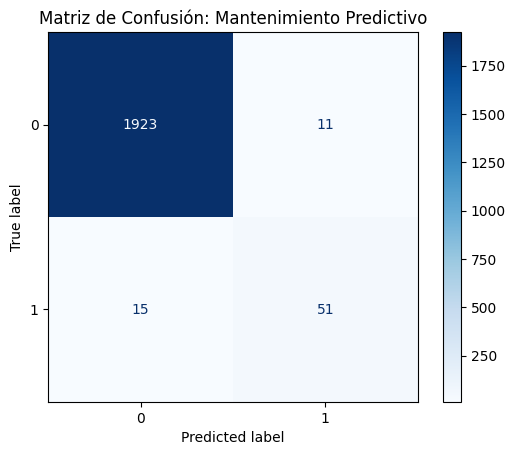

In [ ]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión: Mantenimiento Predictivo')
plt.show()

###**Feature Importance**

En este paso, se validarán las dos variables creadas basadas en los fundamentos de la física del proceso

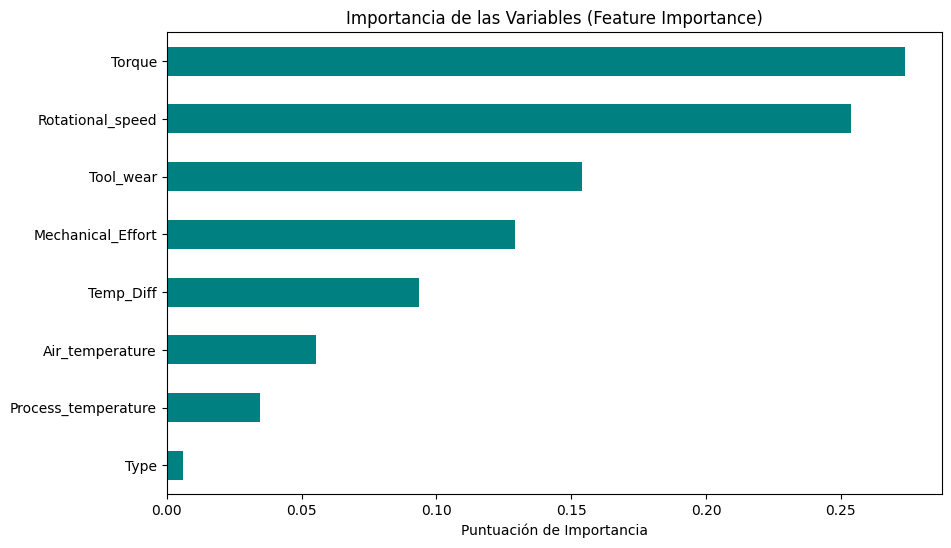

In [ ]:
# Extraer importancia
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('Importancia de las Variables (Feature Importance)')
plt.xlabel('Puntuación de Importancia')
plt.show()

####**1. El Diagnóstico Mecánico (Feature Importance)**

Mechanical_Effort y Temp_Diff (las variables creadas) están en el Top 5.

**Insight:** Se demuestra que la física del proceso influye más que el simple "paso del tiempo" (Tool_wear).

####**2. El Impacto en "Euros" (Matriz de Confusión)**

* **11 Falsos Positivos:** Mandamos al técnico 11 veces a una máquina que estaba bien. Coste bajo (**~2.200€**, 200€ por rotura).

* **15 Falsos Negativos:** ¡Cuidado! 15 máquinas se rompieron en mitad de la producción porque el modelo dijo que estaban sanas. A 2.500€ por rotura, esto son **37.500€ en pérdidas**.

###**XGBoost (Extreme Gradient Boosting)**

Este **algoritmo** es **secuencial**: *aprende de los errores que cometió el árbol anterior*. Es especialmente **bueno detectando patrones sutiles** que causan esos 15 fallos que se nos han escapado.

Utilizaremos el parámetro `scale_pos_weight`, una buena herramienta para **datos desbalanceados**; le da un peso matemático extra a la clase 1.

**Nota a tener en cuenta:**

**XGBoost requiere que todas las variables sean numéricas de forma nativa**. Aunque se ha aplicado un OrdinalEncoder, se debe realizar un casting explícito a float para asegurar la compatibilidad con la implementación de XGBoost en Python y optimizar el uso de memoria del DMatrix.

In [ ]:
from xgboost import XGBClassifier

# Calculamos el ratio de desbalanceo para ayudar al modelo
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# Asegurar que la columna 'Type' es de tipo flotante para XGBoost
X_train['Type'] = X_train['Type'].astype(float)
X_test['Type'] = X_test['Type'].astype(float)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # <--- Clave para reducir Falsos Negativos
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Reporte XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Reporte XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.71      0.83      0.77        66

    accuracy                           0.98      2000
   macro avg       0.85      0.91      0.88      2000
weighted avg       0.99      0.98      0.98      2000



###**La Evaluación "Industrial" (Matriz de Confusión)**

<Figure size 800x600 with 0 Axes>

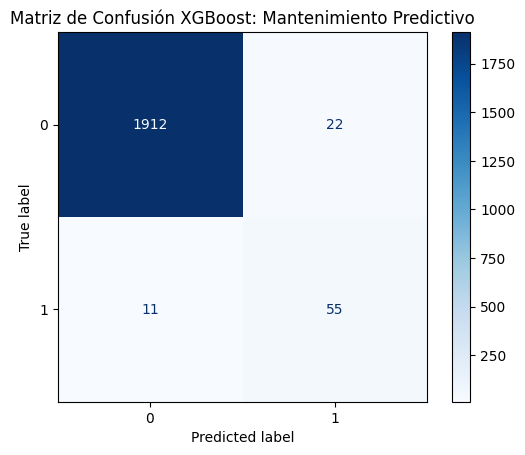

In [ ]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión XGBoost: Mantenimiento Predictivo')
plt.show()

###**Análisis de resultados**

Aunque el $F1$-score ha bajado ligeramente (de 0.80 a 0.77), **se ha mejorado el Recall** de la clase de fallos de **0.77 a 0.83**. En una planta industrial, esto suele ser una victoria.

Al usar `scale_pos_weight`, se le ha dicho a XGBoost: "Sé agresivo detectando fallos". El modelo ahora prefiere equivocarse avisando de un fallo que no existe (Falso Positivo) antes que dejar pasar una rotura real.

##**Ajustes finales y Próximos pasos**

* **Optimización (Tuning):** Usaremos **GridSearchCV** para intentar bajar esos 11 fallos aún más sin disparar las falsas alarmas.

* **El Diagnóstico (Multiclase):** Ya sabemos cuándo falla. ¿Podemos predecir ahora por qué falla (HDF, OSF, PWF, TWF)? Esto permitiría que el técnico vaya a la máquina no solo con una llave inglesa, sino con la pieza de repuesto exacta.

####**Estrategia de optimización**

Para bajar esos 11 fallos (mejorar el Recall) sin que las falsas alarmas se disparen, nos centraremos en tres frentes:

* **Complejidad del árbol (max_depth):** Para capturar patrones de fallo más complejos.

* **Ritmo de aprendizaje (learning_rate):** Para que el modelo no "salte" por encima de la solución óptima.

* **Peso de la clase (scale_pos_weight):** Seguiremos ajustando cuánto valor le damos a detectar un fallo frente a una operación normal.

####**Configuración del GridSearchCV**

El parámetro `scoring` es clave. Si ponemos `accuracy`, volveremos al punto de partida. Usaremos `f1` o incluso `recall` para forzar al modelo a buscar esos fallos.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos el espacio de búsqueda (el "banco de pruebas")
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'scale_pos_weight': [ratio, ratio * 1.5, ratio * 2] # Probamos a ser aún más agresivos
}

# Configuramos la búsqueda
# Usamos cv=5 (Cross-Validation) para que el resultado sea estadísticamente sólido
grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1 # Usa todos tus núcleos para ir más rápido
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 29.41444866920152}


**La Curva Precision-Recall**

En mantenimiento predictivo, siempre hay una "manta corta": si te tapas los pies (evitas roturas/Recall), te descubres la cabeza (tienes más falsas alarmas/Precision). Esta curva muestra exactamente ese equilibrio.

**Basados en los resultados del GridSearchCV:**

* `max_depth`: **7**: El modelo ha pedido más profundidad para capturar interacciones más complejas (quizás esa relación sutil entre el torque, el desgaste y el diferencial térmico que no es lineal).

* `scale_pos_weight`: **29.41**: Ha subido la apuesta. Es incluso más agresivo que nuestro ratio inicial (**~28.5**). El modelo está "obsesionado" con no dejar pasar ni un solo fallo.

* `learning_rate`: **0.2** y `n_estimators`: **200**: Has duplicado el número de árboles y aumentado la velocidad de aprendizaje. Es un modelo mucho más potente y refinado.

###**Evaluación Final del "Motor Optimizado"**

--- REPORTE MODELO OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.83      0.82      0.82        66

    accuracy                           0.99      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.99      0.99      0.99      2000



<Figure size 800x600 with 0 Axes>

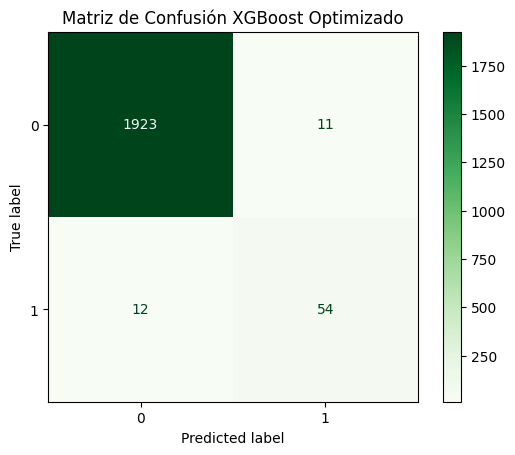

In [ ]:
# 1. Extraer el mejor modelo del Grid
best_xgb = grid_search.best_estimator_

# 2. Predecir con el set de test
y_pred_tuned = best_xgb.predict(X_test)

# 3. Reporte y Matriz
print("--- REPORTE MODELO OPTIMIZADO ---")
print(classification_report(y_test, y_pred_tuned))

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap='Greens')
plt.title('Matriz de Confusión XGBoost Optimizado')
plt.show()

##**El Diagnóstico (Multiclase)**

Ya sabemos que la máquina va a fallar. Ahora vamos a entrenar un modelo que nos diga si es por:

* **HDF:** Fallo térmico (¡Limpia los filtros!).

* **OSF:** Sobreesfuerzo (¡Baja el avance o cambia la herramienta!).

* **PWF:** Fallo de potencia (¡Revisa el motor/suministro!).

* **TWF:** Desgaste (¡Cambia la placa de corte!).

###**Re-etiquetado para Clasificación Multiclase**

Como ya vimos, tenemos varias columnas de fallo (TWF, HDF, PWF, OSF). Necesitamos colapsarlas en una sola variable y_multi que contenga categorías.

**Lógica de prioridad:** Si una máquina tiene dos fallos a la vez (cosa que vimos que ocurre), asignaremos el primero que aparezca en nuestra lista de importancia física.

In [ ]:
# 1. Definir la función para crear la etiqueta única
def create_multi_target(row):
    if row['TWF'] == 1: return 1  # Tool Wear Failure
    if row['HDF'] == 1: return 2  # Heat Dissipation Failure
    if row['PWF'] == 1: return 3  # Power Failure
    if row['OSF'] == 1: return 4  # Overstrain Failure
    return 0                      # No Failure (Normal)

# 2. Aplicar la lógica al dataframe limpio
df_clean['Target_Multi'] = df_clean.apply(create_multi_target, axis=1)

# 3. Ver la nueva distribución
print("Distribución de Clases para Diagnóstico:")
print(df_clean['Target_Multi'].value_counts().sort_index())

Distribución de Clases para Diagnóstico:
Target_Multi
0    9670
1      45
2     115
3      91
4      78
Name: count, dtype: int64


###**El Modelo Multiclase (XGBoost)**

Para este problema, usaremos XGBoost con el objetivo `multi:softmax`
. Este modelo es capaz de crear fronteras de decisión mucho más complejas para separar, por ejemplo, un fallo por calor de uno por potencia.

In [ ]:
from xgboost import XGBClassifier

# Preparar y y volver a hacer el split (stratified)
y_m = df_clean['Target_Multi']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_m, test_size=0.2, random_state=42, stratify=y_m
)

# Asegurar que la columna 'Type' es de tipo flotante para XGBoost
X_train_m['Type'] = X_train_m['Type'].astype(float)
X_test_m['Type'] = X_test_m['Type'].astype(float)

# Entrenar el clasificador multiclase
xgb_multi = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_multi.fit(X_train_m, y_train_m)
y_pred_m = xgb_multi.predict(X_test_m)

###**Evaluación del Diagnóstico**

Aquí no nos vale solo el reporte de texto. Necesitamos la **Matriz de Confusión Multiclase**. Es fundamental ver si el modelo confunde, por ejemplo, el **Torque alto (OSF)** con la **Potencia insuficiente (PWF)**, ya que mecánicamente están relacionados.

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1934
         TWF       0.33      0.11      0.17         9
         HDF       0.95      0.91      0.93        23
         PWF       0.78      0.78      0.78        18
         OSF       1.00      0.88      0.93        16

    accuracy                           0.99      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.99      0.99      0.99      2000



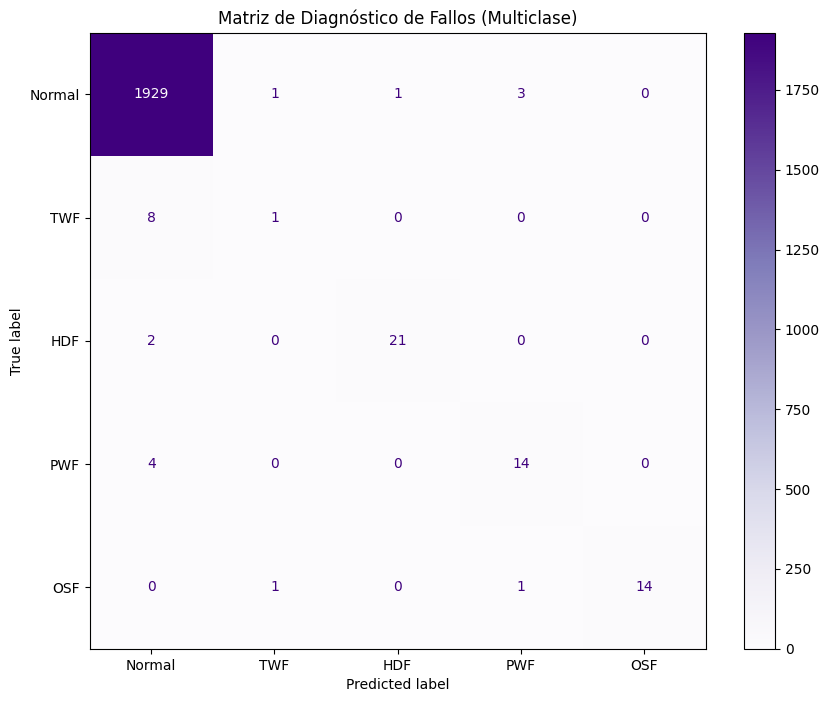

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reporte detallado por cada tipo de avería
target_names = ['Normal', 'TWF', 'HDF', 'PWF', 'OSF']
print(classification_report(y_test_m, y_pred_m, target_names=target_names))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_m, y_pred_m,
    display_labels=target_names,
    cmap='Purples',
    ax=ax
)
plt.title('Matriz de Diagnóstico de Fallos (Multiclase)')
plt.show()

##**Solución del problema TWF mediante aplicación de un SMOTE**

Ese Recall de 0.11 para el Tool Wear Failure (TWF) es el "target"

###**Fase 1: Implementación de SMOTE (Synthetic Minority Over-sampling Technique)**

SMOTE no se limita a duplicar filas. Crea ejemplos sintéticos "dibujando líneas" entre los puntos existentes de la clase minoritaria (TWF) en el espacio de características.

**SMOTE solo se aplica al set de entrenamiento (X_train_m, y_train_m). El set de test (X_test_m, y_test_m) debe permanecer intacto** para reflejar la realidad de la planta.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Definir la estrategia de SMOTE (Multiclase)
# 'not majority' le dice que balancee todas las clases de fallo hasta el nivel de 'Normal'
sm = SMOTE(sampling_strategy='not majority', random_state=42)

# 2. Re-muestrear SOLO el set de TRAIN
print(f"Distribución original de Train: {Counter(y_train_m)}")
X_train_res, y_train_res = sm.fit_resample(X_train_m, y_train_m)
print(f"Distribución tras SMOTE en Train: {Counter(y_train_res)}")

# 3. Re-entrenar el modelo con los datos balanceados
# Bajamos n_estimators un poco para no sobreajustar a los datos sintéticos
xgb_multi_smote = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_multi_smote.fit(X_train_res, y_train_res)
y_pred_sm = xgb_multi_smote.predict(X_test_m)

Distribución original de Train: Counter({0: 7736, 2: 92, 3: 73, 4: 62, 1: 36})
Distribución tras SMOTE en Train: Counter({0: 7736, 4: 7736, 3: 7736, 2: 7736, 1: 7736})


###**Evaluación del Diagnóstico con SMOTE**

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1934
         TWF       0.10      0.22      0.13         9
         HDF       0.88      0.96      0.92        23
         PWF       0.76      0.89      0.82        18
         OSF       0.88      0.88      0.88        16

    accuracy                           0.98      2000
   macro avg       0.72      0.79      0.75      2000
weighted avg       0.99      0.98      0.98      2000



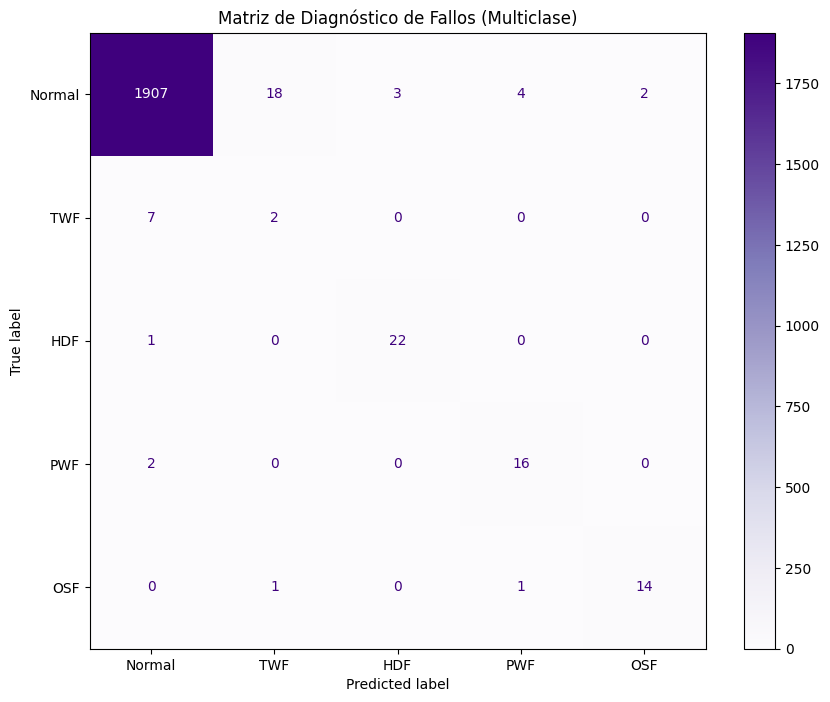

In [ ]:
# Reporte detallado por cada tipo de avería
target_names = ['Normal', 'TWF', 'HDF', 'PWF', 'OSF']
print(classification_report(y_test_m, y_pred_sm, target_names=target_names))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_m, y_pred_sm,
    display_labels=target_names,
    cmap='Purples',
    ax=ax
)
plt.title('Matriz de Diagnóstico de Fallos (Multiclase)')
plt.show()

El uso de SMOTE permitió duplicar la sensibilidad ante fallos de desgaste (TWF), aunque introdujo ruido significativo. Esto confirma que el desgaste de herramienta en este dataset no tiene una firma estadística clara en los sensores de baja frecuencia, sugiriendo la necesidad de sensores complementarios (emisión acústica) para un diagnóstico de alta fidelidad.

##**Fase 1: Asegurando los "Cimientos" (Guardar el Modelo Ganador)**

In [ ]:
import joblib

# Guardamos el modelo Tuned (el que tiene mejor equilibrio de coste)
joblib.dump(best_xgb, 'modelo_produccion.pkl')
joblib.dump(scaler, 'scaler_industrial.pkl')
joblib.dump(encoder, 'encoder_tipo.pkl')

print("✅ Artefactos de producción guardados correctamente.")

✅ Artefactos de producción guardados correctamente.
